In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score,
                              roc_curve, f1_score)
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', palette='Set2')
np.random.seed(42)

In [3]:
# Q1.1 Chargez le dataset. Renommez 2urvived en Survived. Gardez uniquement les colonnes utiles : Age, Fare, Sex, Pclass, sibsp, Parch, Survived. 
# Utilisez les 891 premiers passagers (train set réel — les autres n'ont pas de vraie valeur Survived).

import pandas as pd
import numpy as np 

df = pd.read_csv('train_and_test2.csv', encoding = 'Utf-8', sep = ',') # chargement du dataset
print(df) # affichage du dataset

      Passengerid   Age      Fare  Sex  sibsp  zero  zero.1  zero.2  zero.3  \
0               1  22.0    7.2500    0      1     0       0       0       0   
1               2  38.0   71.2833    1      1     0       0       0       0   
2               3  26.0    7.9250    1      0     0       0       0       0   
3               4  35.0   53.1000    1      1     0       0       0       0   
4               5  35.0    8.0500    0      0     0       0       0       0   
...           ...   ...       ...  ...    ...   ...     ...     ...     ...   
1304         1305  28.0    8.0500    0      0     0       0       0       0   
1305         1306  39.0  108.9000    1      0     0       0       0       0   
1306         1307  38.5    7.2500    0      0     0       0       0       0   
1307         1308  28.0    8.0500    0      0     0       0       0       0   
1308         1309  28.0   22.3583    0      1     0       0       0       0   

      zero.4  ...  zero.12  zero.13  zero.14  Pclas

In [4]:
# Renommez 2urvived en Survived
df.rename(columns = {'2urvived':'Survived'}, inplace = True)
print(df)

      Passengerid   Age      Fare  Sex  sibsp  zero  zero.1  zero.2  zero.3  \
0               1  22.0    7.2500    0      1     0       0       0       0   
1               2  38.0   71.2833    1      1     0       0       0       0   
2               3  26.0    7.9250    1      0     0       0       0       0   
3               4  35.0   53.1000    1      1     0       0       0       0   
4               5  35.0    8.0500    0      0     0       0       0       0   
...           ...   ...       ...  ...    ...   ...     ...     ...     ...   
1304         1305  28.0    8.0500    0      0     0       0       0       0   
1305         1306  39.0  108.9000    1      0     0       0       0       0   
1306         1307  38.5    7.2500    0      0     0       0       0       0   
1307         1308  28.0    8.0500    0      0     0       0       0       0   
1308         1309  28.0   22.3583    0      1     0       0       0       0   

      zero.4  ...  zero.12  zero.13  zero.14  Pclas

In [5]:
df= df.loc[0:890, ['Age', 'Fare', 'Sex', 'Pclass', 'sibsp', 'Parch', 'Survived']].copy() # selection des colonne importante et des 891 premiers passagers et copy dy dataset pour travail dessus 
print(df)

      Age     Fare  Sex  Pclass  sibsp  Parch  Survived
0    22.0   7.2500    0       3      1      0         0
1    38.0  71.2833    1       1      1      0         1
2    26.0   7.9250    1       3      0      0         1
3    35.0  53.1000    1       1      1      0         1
4    35.0   8.0500    0       3      0      0         0
..    ...      ...  ...     ...    ...    ...       ...
886  27.0  13.0000    0       2      0      0         0
887  19.0  30.0000    1       1      0      0         1
888  28.0  23.4500    1       3      1      2         0
889  26.0  30.0000    0       1      0      0         1
890  32.0   7.7500    0       3      0      0         0

[891 rows x 7 columns]


In [6]:
# Q1.2 Vérifiez rapidement : shape, valeurs manquantes, taux de survie.
print(df.shape) # affichage des dimensions du dataset

(891, 7)


In [7]:
# determinantion des valeurs manquante
print(df.isnull())

       Age   Fare    Sex  Pclass  sibsp  Parch  Survived
0    False  False  False   False  False  False     False
1    False  False  False   False  False  False     False
2    False  False  False   False  False  False     False
3    False  False  False   False  False  False     False
4    False  False  False   False  False  False     False
..     ...    ...    ...     ...    ...    ...       ...
886  False  False  False   False  False  False     False
887  False  False  False   False  False  False     False
888  False  False  False   False  False  False     False
889  False  False  False   False  False  False     False
890  False  False  False   False  False  False     False

[891 rows x 7 columns]


In [8]:
# determinantion du nombre de valeurs manquante
print(df.isnull().sum())

Age         0
Fare        0
Sex         0
Pclass      0
sibsp       0
Parch       0
Survived    0
dtype: int64


In [9]:
# determinantion du pourcentage de valeurs manquante
print(df.isnull().sum()/len(df)*100)

Age         0.0
Fare        0.0
Sex         0.0
Pclass      0.0
sibsp       0.0
Parch       0.0
Survived    0.0
dtype: float64


interpretation
le dataset est constitué de 891 données liées à 7 features et il ne contient l'intergralite de ses ses informations(données)

Feature	    Type                    Skewness	Valeurs manquantes	 Action preprocessing	       Justification EDA
Age	        Numérique continue	    ~0.54	          0		         la standardisation(Scaler)    la distributionest legeremement asymétrique mais                                                                                                     exploitable 
Fare	    Numérique continue	    ~4.37	          0		         la transformation                                                                                                                                   logarithmique + scaling       une forte asymétrie et outliers 
Sex	        Binaire (0/1)	        ~0.62	          0		         l'encodage binaire            variable catégorielle
Pclass	    Ordinale (1/2/3)	    ~-0.63	          0		         on le garde ainsi             elles ont un orde naturel/variable odinale
sibsp	    Entier	                ~3.7	          0		         scaling éventuel               variable  numérique discrète
Parch	    Entier	                ~2.75	          0		         scaling éventuel               variable numérique discrète


In [10]:
print(f'le skewness du sex est : {df['Sex'].skew().round(2)}')
print(f'le skewness du Fare est : {df['Fare'].skew().round(2)}')
print(f'le skewness du Pclass est : {df['Pclass'].skew().round(2)}')
print(f'le skewness du sibsp est : {df['sibsp'].skew().round(2)}')
print(f'le skewness du Parch est : {df['Parch'].skew().round(2)}')

le skewness du sex est : 0.62
le skewness du Fare est : 4.79
le skewness du Pclass est : -0.63
le skewness du sibsp est : 3.7
le skewness du Parch est : 2.75


In [29]:
# Q2.1 Créez les features suivantes et justifiez chacune :
df['fare_log']    = np.log1p(df['Fare'])
df['family_size'] = df['sibsp'] + df['Parch'] + 1
df['is_alone']    = (df['family_size'] == 1).astype(int)

In [30]:
# Pour chaque nouvelle feature, calculez sa corrélation avec Survived et comparez-la à la feature originale.
#La transformation améliore-t-elle le signal ?
print(f'la correlation entre Survived et fare_log est de : {df['fare_log'].corr(df['Survived']).round(4)}')
print(f'la correlation entre Survived et family_size est de : {df['family_size'].corr(df['Survived']).round(3)}')
print(f'la correlation entre Survived et is_alone est de : {df['is_alone'].corr(df['Survived']).round(3)}')

la correlation entre Survived et fare_log est de : 0.3299
la correlation entre Survived et family_size est de : 0.017
la correlation entre Survived et is_alone est de : -0.203


In [31]:
print(f'la correlation entre Survived et fare est de : {df['Fare'].corr(df['Survived']).round(4)}')

la correlation entre Survived et fare est de : 0.2573


oui la transformation ameliore le signal

In [32]:
# Q2.2 ★ Créez la variable age_class_interaction = Age × (1 si Pclass==1 else 0) ou tout autre feature d'interaction pertinente selon votre EDA.
# Calculez sa corrélation avec Survived.
df['age_class_interaction'] = df['Age'] * (df['Pclass'] == 1).astype(int)
print(df)

      Age     Fare  Sex  Pclass  sibsp  Parch  Survived  \
0    22.0   7.2500    0       3      1      0         0   
1    38.0  71.2833    1       1      1      0         1   
2    26.0   7.9250    1       3      0      0         1   
3    35.0  53.1000    1       1      1      0         1   
4    35.0   8.0500    0       3      0      0         0   
..    ...      ...  ...     ...    ...    ...       ...   
886  27.0  13.0000    0       2      0      0         0   
887  19.0  30.0000    1       1      0      0         1   
888  28.0  23.4500    1       3      1      2         0   
889  26.0  30.0000    0       1      0      0         1   
890  32.0   7.7500    0       3      0      0         0   

     age_class_interaction  fare_log  family_size  is_alone  
0                      0.0  2.110213            2         0  
1                     38.0  4.280593            2         0  
2                      0.0  2.188856            1         1  
3                     35.0  3.990834       

In [33]:
print('la corrélation est de : ', df['age_class_interaction'].corr(df['Survived']).round(2)) 

la corrélation est de :  0.22


In [34]:
# Q2.3 Séparez les données en train set (80%) et test set (20%). Utilisez stratify=y 
#et expliquez dans une cellule Markdown pourquoi ce paramètre est important ici. 
x = df.drop('Survived', axis = 1)
y = df['Survived']

x_train, x_test, y_train, y_test = train_test_split( x, y, test_size = 0.2, stratify = y, random_state = 42)
# test_size = 0.2  c'est pour donner 20% des données utilisées pour les test
# random_state = 42 c'est pour rendre le résultat reproductible
# stratify = y pour équilibrer le dataset en censervant les proportions des classes

le parametre stratify=y permet de conserver la même proportion de classe dans les ensemble d'entraînement et de test. le dataset etant desequilibrée car il y a plus de mort que de survivant, donc l'utilisation du dataset ainsi pourrait produit des ensembles avec des proportion differentes et donc pourrait fausser l'apprentissage et mêmel'evolution du modèle. Donc stractification garantira une meilleure representativité des données.

In [35]:
# Q2.4 Vérifiez que le ratio de survivants est similaire dans le train et le test set. Affichez les deux proportions.
print(f"les proportion du train set sont : {y_train.value_counts(normalize = True)}")

print(f"les proportion du test set sont : {y_test.value_counts(normalize = True)}")

les proportion du train set sont : Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64
les proportion du test set sont : Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [36]:
# Q2.5 Appliquez un StandardScaler sur les features numériques continues uniquement (Age, fare_log). 
# Les features binaires (Sex, is_alone) et discrètes (Pclass, family_size) ne sont pas normalisées.
# print(x_train.columns)
cols_to_scale = ['Age','fare_log'] # selection des colonnes continues à normaliser
scaler = StandardScaler() # creation du scaler
x_train[cols_to_scale] = scaler.fit_transform(x_train[cols_to_scale]) # fit sur le test set
x_test[cols_to_scale] = scaler.transform(x_test[cols_to_scale]) # la transformation sur le test

Index(['Age', 'Fare', 'Sex', 'Pclass', 'sibsp', 'Parch',
       'age_class_interaction', 'fare_log', 'family_size', 'is_alone'],
      dtype='object')


on normalise uniquement les variable numerique continues car elles possédent des échelles differentes. donc on fait la standardisation pour les remettre sur la même échelle.
les variable binaire sex et is_alone ne sont pas normalisées car elles continuent uniquement de 0 et de 1
et les variables discrètes ou ordinales Pclass et family_size gardent aussi leur signification numérique et leur ordre naturel.

Question critique Q2.6 : Qu'est-ce que le data leakage ? Pourquoi est-il interdit de fit() le scaler sur le test set ? Répondez dans une cellule Markdown.

le data leakage c'est lorsqu'on utilise le test set pendant l'entraînement.
il est interdit de fit() du scaler sur le test set ça cause un leakage donc une fuite d'information et invalide l'evaluation 

In [41]:
# Q3.1 Entraînez une régression logistique. Pensez au déséquilibre des classes.
log_reg = LogisticRegression(
    # Complétez les hyperparamètres : 
    class_weight='balanced', # - Gérez le déséquilibre des classes (class_weight=?)
     random_state=42, # - random_state=42
   max_iter = 1000 # - max_iter suffisant pour la convergence
)

log_reg.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


la regression logistique est utilisée pour le probleme de classifaication binaire. le parametre class_weight= 'balanced permet de compenser le desaquilibre des classes en donnant plus d'importance à la classe minoritaire. random_state=42 garantit la reproductibilité et max_iter = 1000 permet au modèle d'avoir suffisamment d'itérations pour la convergence.

In [45]:
# Q3.2 Affichez les coefficients du modèle. Créez un barplot horizontal trié par valeur absolue des coefficients.
# Identifiez les 2 features les plus influentes.
coefs = pd.DataFrame({'Feature' : x_train.columns, 'coefs' : log_reg.coef_[0]})
print(type(coefs))
print(coefs)

<class 'pandas.core.frame.DataFrame'>
                 Feature     coefs
0                    Age -0.570406
1                   Fare -0.003887
2                    Sex  2.505128
3                 Pclass -0.541094
4                  sibsp -0.257820
5                  Parch -0.034616
6  age_class_interaction  0.013292
7               fare_log  0.595513
8            family_size -0.268967
9               is_alone -0.489875


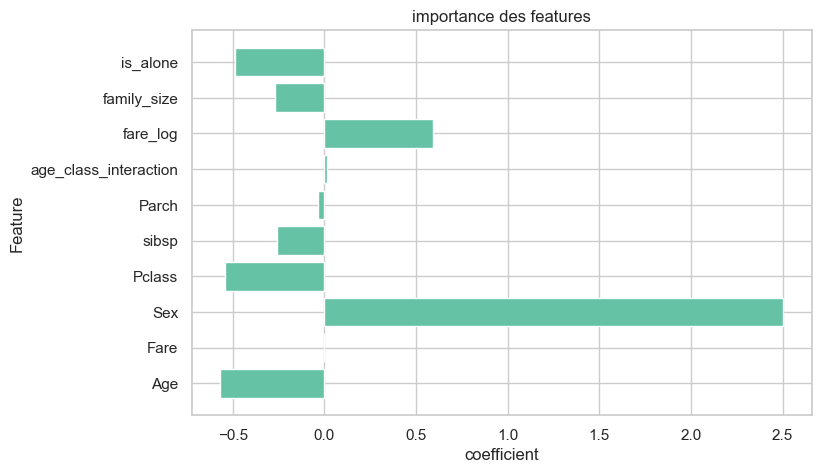

In [47]:

plt.figure(figsize=(8,5))
plt.barh(coefs['Feature'],coefs['coefs'])
plt.xlabel('coefficient')
plt.ylabel('Feature')
plt.title('importance des features')
plt.show()

In [51]:
top_2 = coefs.loc[coefs['coefs'].abs().sort_values(ascending = False).head(2).index]
print(top_2[['Feature','coefs']])

    Feature     coefs
2       Sex  2.505128
7  fare_log  0.595513


Q3.3 Le coefficient de Sex est-il positif ou négatif ? Qu'est-ce que cela signifie ? (Rappel : Sex=1 pour les femmes, Sex=0 pour les hommes.)
si le coef est positif alors être une femme augmente la probabilité de survie. dont dans le titanic les femmes avaient plus de chances de survivre 
si le coef est négatif etres une femme diminue la probabilité de survie. donc sur le titanic ça contredirait le comportement réel observé

Accuracy : 0.8044692737430168


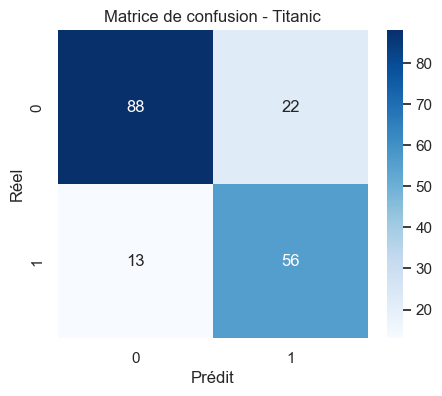


Classification Report :

              precision    recall  f1-score   support

           0       0.87      0.80      0.83       110
           1       0.72      0.81      0.76        69

    accuracy                           0.80       179
   macro avg       0.79      0.81      0.80       179
weighted avg       0.81      0.80      0.81       179

AUC-ROC : 0.8491436100131752


In [55]:
# Q3.4 Évaluez le modèle avec toutes les métriques suivantes. Pour chaque métrique, rédigez une phrase d'interprétation en contexte Titanic.
# Prédictions
y_pred = log_reg.predict(x_test)
y_pred_proba = log_reg.predict_proba(x_test)[:, 1]

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy :", acc)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion - Titanic")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# Classification report
print("\nClassification Report :\n")
print(classification_report(y_test, y_pred))

# AUC-ROC
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC-ROC :", auc)

Accuracy mesure la proportion de prédictions correctes.
Elle indique globalement à quel point le modèle prédit correctement la survie des passagers du Titanic.

Matrice de confusion, Elle permet de distinguer :
les survivants correctement prédits (TP)
les morts correctement prédits (TN)
les erreurs du modèle (FP et FN)

Dans le contexte Titanic, une erreur importante est de mal prédire les survivants.

Classification report
Precision : parmi les passagers prédits survivants, combien ont réellement survécu
Recall : parmi les survivants réels, combien ont été correctement détectés
F1-score : compromis entre précision et rappel

AUC-ROC
L’AUC mesure le niveau de distinction sur tous les seuils
proche de 1 → excellent modèle
0.5 → modèle aléatoire